# 🎬 Movie Recommendation System Using Collaborative Filtering

# 1. Business Understanding

Streaming platforms such as Netflix and Amazon Prime contain a large number of movies.

This creates a problem where users struggle to find movies they want to watch due to too many choices.

The goal of this project is to build a recommendation system that suggests movies to users based on their past ratings.

## 1.1 Stakeholders

The main stakeholders in this project are:

- Streaming platforms (e.g., Netflix-style services)
- Movie viewers (users)
- Data science teams

These stakeholders benefit from improved movie recommendations that enhance user experience and engagement.

## 1.2 Business Value

This system provides value by:

- Helping users find movies they are likely to enjoy
- Increasing user engagement on streaming platforms
- Improving content discovery efficiency
- Reducing time spent searching for movies

## Conclusion

This project addresses a real-world problem of helping users discover movies in large streaming libraries.

It improves user satisfaction and helps platforms increase engagement through better recommendations.


# 2. Data Understanding – Movie Recommendation System (MovieLens 100K)

## 📦 Data Source

This project uses the MovieLens 100K dataset provided by GroupLens Research (University of Minnesota).

The dataset is widely used in recommendation system research and contains real user ratings of movies.

## 2.1 Dataset Description

The dataset contains three main files:

- u.data → user ratings (userId, movieId, rating, timestamp)
- u.item → movie information (movie titles and genres)
- u.user → user demographic information (age, gender, occupation)

For this project, we mainly use:
- userId
- movieId
- rating

In [298]:
#1. loading the data
import pandas as pd

# Load ratings data (main dataset for recommendation system)
ratings = pd.read_csv(
    "data/ml-100k/u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

# Load full movie information including genres
movies_raw = pd.read_csv(
    "data/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

# Extract just movieId and title for common use
movies = movies_raw[[0, 1]]

# Rename columns for clarity
movies.columns = ["movieId", "title"]

In [299]:
#2. checking the size of the datasets
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings shape: (100000, 4)
Movies shape: (1682, 2)


In [300]:
#3. Check column names
print("Ratings columns:", ratings.columns)
print("Movies columns:", movies.columns)

Ratings columns: Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Movies columns: Index(['movieId', 'title'], dtype='object')


In [301]:
#4. View first rows of dataset
ratings.head()

,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [302]:
movies.head()

,movieId,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [303]:
#5. Summary of the ratings dataset
ratings.describe()

,userId,movieId,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


### 2.2 visualisation

this shows how one understand data 

presents the size of dataset and descriptive statistics for all features used in analysis

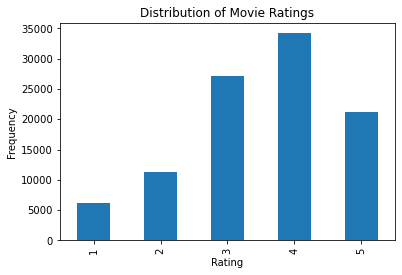

In [304]:
# 1. distribution of ratings
import matplotlib.pyplot as plt

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

## Rating Distribution

This graph shows how users rate movies on the platform.

Understanding rating distribution is important because recommendation models learn from these ratings. If ratings are heavily concentrated around certain values, this may influence model predictions.

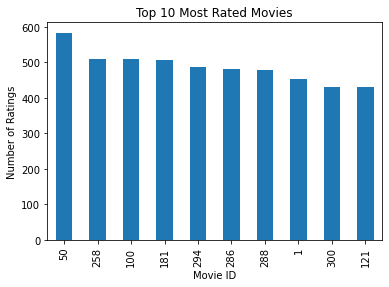

In [305]:
# 2. most rated movies
movie_counts = ratings["movieId"].value_counts().head(10)

movie_counts.plot(kind="bar")

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.show()

## Most Rated Movies

This visualization identifies movies that receive the highest number of ratings.

Popular movies often have more reliable rating information because they have been evaluated by many users.

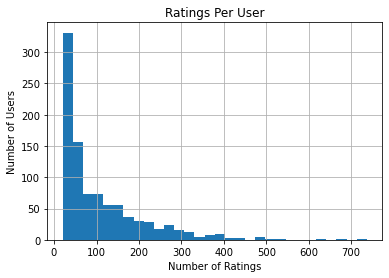

In [306]:
# 3. ratings per user
user_counts = ratings.groupby("userId")["rating"].count()

user_counts.hist(bins=30)

plt.title("Ratings Per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

## User Activity

This visualization shows how many ratings each user has submitted.

Understanding user activity helps determine whether sufficient information exists to learn user preferences.

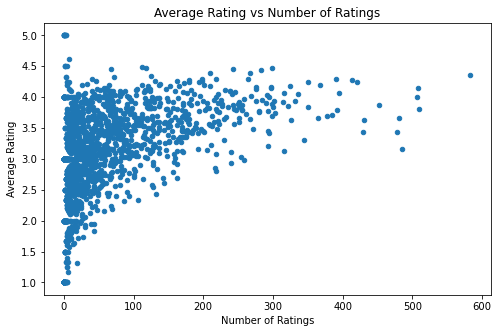

In [307]:
# 3. average rating by movie popularity
# Calculate movie statistics
movie_stats = ratings.groupby("movieId").agg({
    "rating": ["count", "mean"]
})

movie_stats.columns = ["rating_count", "average_rating"]

# Scatter plot
movie_stats.plot(
    kind="scatter",
    x="rating_count",
    y="average_rating",
    figsize=(8, 5)
)

plt.title("Average Rating vs Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

## Relationship Between Popularity and Rating

This scatter plot compares the number of ratings a movie receives with its average rating.

The visualization helps identify whether highly-rated movies are also popular among users. This insight is useful because recommendation systems often rely on both popularity and user preferences.

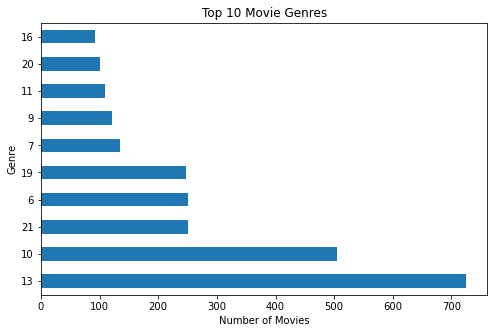

In [308]:
# 4. top genre in dataset
# Genre columns in MovieLens 100K start after column 4
genre_counts = movies_raw.iloc[:, 5:].sum().sort_values(ascending=False)

genre_counts.head(10).plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

## Genre Distribution

This chart shows the most common genres in the dataset.

Understanding genre distribution helps identify whether certain movie categories dominate the dataset and may influence recommendation results.

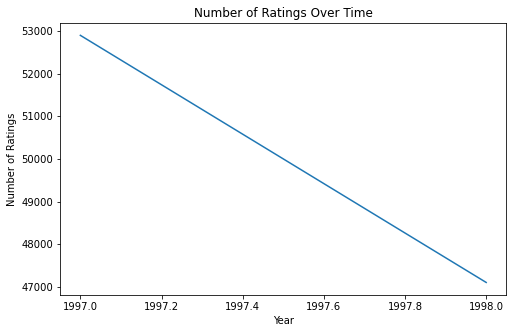

In [309]:
# 5. rating over time
# Convert timestamp to datetime
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")

# Count ratings by year
ratings_by_year = ratings.groupby(
    ratings["date"].dt.year
).size()

ratings_by_year.plot(
    kind="line",
    figsize=(8, 5)
)

plt.title("Number of Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.show()

## Ratings Activity Over Time

This line chart shows how rating activity changes over time.

Analyzing temporal trends helps us understand user engagement patterns and provides additional context about the dataset.

Each row in the ratings dataset represents:

A user (userId) giving a rating (1–5) to a movie (movieId).

This forms a user-item interaction matrix, which is the foundation of recommendation systems.

## 2.3 why this data
This dataset is useful because:

- It contains real user preferences (ratings)
- It allows prediction of missing ratings
- It helps find users with similar tastes
- It supports collaborative filtering models like SVD

## 2.4 features used
We focus on:

- userId → identifies users
- movieId → identifies movies
- rating → user preference score (1–5)

These features are essential for learning user behavior patterns.

## 2.5 limitations
- Only explicit ratings are available (no watch history)
- Cold start problem exists for new users
- Data is sparse (many missing user-movie combinations)
- No modern behavioral signals like clicks or watch time

# 3 Data Preparation 

In this stage, we prepare the raw MovieLens dataset so it can be used for building a recommendation model.

This includes:
- Loading the data
- Merging datasets
- Checking for missing values
- Creating a user-item matrix
- Splitting data into training and testing sets

These steps make the data suitable for collaborative filtering models.

### 3.1 loading data

In [310]:
# 1. load the data
import pandas as pd

# Load ratings data
# This contains user ratings for movies
ratings = pd.read_csv(
    "data/ml-100k/u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

# Load movie information
# This helps us map movie IDs to readable movie titles
movies = pd.read_csv(
    "data/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)[[0, 1]]

# Rename columns for clarity
movies.columns = ["movieId", "title"]

### 3.2 merge ratings and movies

In [311]:
# 2. We combine ratings with movie titles
# This helps us understand which movie each rating belongs to

df = pd.merge(ratings, movies, on="movieId")

# Show first few rows to confirm merge worked
df.head()

,userId,movieId,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,63,242,3,875747190,Kolya (1996)
2,226,242,5,883888671,Kolya (1996)
3,154,242,3,879138235,Kolya (1996)
4,306,242,5,876503793,Kolya (1996)


This step joins the ratings dataset with the movies dataset.

Why this is important:
- Ratings alone only contain movie IDs (not names)
- Merging allows us to interpret results in a human-readable way

### 3.3 check data quality

In [312]:
# Check for missing values in each column
df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
title        0
dtype: int64

This step checks if any data is missing.

Why this matters:
- Missing values can cause errors in modeling
- MovieLens dataset is already clean, but we verify it anyway

### 3.4 filter valid ratings

In [313]:
# Ensure ratings are within valid range (1 to 5)
df = df[(df["rating"] >= 1) & (df["rating"] <= 5)]
df["rating"].describe()

count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

We filter ratings to ensure data consistency.

Why:
- MovieLens ratings are expected to be between 1 and 5
- This removes any incorrect or corrupted values

### 3.5 creating user item matrix

In [314]:
# Create a matrix where:
# rows = users
# columns = movies
# values = ratings

user_item_matrix = df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This is one of the most important steps in recommendation systems.

We convert the dataset into a user-item matrix:

- Each row represents a user
- Each column represents a movie
- Each cell contains the rating given by a user to a movie

This structure is required for collaborative filtering models like SVD.

### 3.6 checking the sparsity

In [315]:
# 1.Count missing values in the matrix
missing_values = user_item_matrix.isnull().sum().sum()
print("Total missing values in user-item matrix:", missing_values)



Total missing values in user-item matrix: 1486126


In [316]:
# 2. total possible values in the matrix
total_values = user_item_matrix.size
print("Total possible values in user-item matrix:", total_values)

Total possible values in user-item matrix: 1586126


In [317]:
# 3. Calculate sparsity
print("missing_values:", missing_values)
print("Sparsity(%):", (missing_values / total_values) * 100)

missing_values: 1486126
Sparsity(%): 93.69533063577546


This step measures how sparse the dataset is.

Why this matters:
- Most users have NOT rated most movies
- This sparsity is what makes recommendation systems challenging
- Collaborative filtering is designed to handle this issue

### 3.7 train split

In [318]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# Training data is used to build the model
# Test data is used to evaluate the model

train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Train size:", train_data.shape)
print("Test size:", test_data.shape)

Train size: (80000, 5)
Test size: (20000, 5)


We split the dataset into training and testing sets.

Why:
- Training data is used to build the model
- Test data is used to evaluate performance on unseen data
- This ensures fair evaluation and prevents overfitting

In this stage, we prepared the dataset for modeling by:

- Loading raw data
- Merging datasets for interpretability
- Checking and confirming data quality
- Creating a user-item matrix
- Splitting data into training and testing sets

The dataset is now ready for building a collaborative filtering recommendation model.

## 4. modeling

The goal of this stage is to build and compare recommendation models.

Following the CRISP-DM methodology and project requirements, modeling will begin with a simple baseline model before progressing to a more sophisticated collaborative filtering model.

This iterative approach allows us to determine whether increasing model complexity improves recommendation performance.

### 4.1 Baseline model
Before building a recommendation system, it is important to establish a baseline for comparison.

The baseline model predicts the average movie rating for every user.

Although this approach ignores individual user preferences, it provides a benchmark against which more advanced models can be evaluated.

In [319]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Average rating in training data
baseline_prediction = train_data["rating"].mean()

# Predict same rating for every observation
baseline_predictions = np.full(
    len(test_data),
    baseline_prediction
)

# Evaluate baseline
baseline_rmse = np.sqrt(
    mean_squared_error(
        test_data["rating"],
        baseline_predictions
    )
)

baseline_mae = mean_absolute_error(
    test_data["rating"],
    baseline_predictions
)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 1.1308617804162673
Baseline MAE: 0.9495255499999999


### Baseline model insight

The baseline model predicts the same rating for every movie regardless of the user.

This approach does not capture individual preferences and is therefore expected to perform poorly.

However, it establishes a benchmark that more sophisticated recommendation models should outperform.

### 4.2 collaborative filtering 
#### Singular Value Decomposition

The baseline model ignores user behavior.

To improve recommendations, a collaborative filtering model is introduced using Singular Value Decomposition (SVD).

SVD learns latent relationships between users and movies by analyzing historical rating patterns.

This allows the model to personalize recommendations based on user preferences.

In [320]:
!pip install scikit-surprise

In [321]:
# prepare data for surprise 
from surprise import Dataset
from surprise import Reader

reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    df[["userId", "movieId", "rating"]],
    reader
)

In [322]:
# train SVD model
from surprise import SVD
from surprise.model_selection import train_test_split

# Split for Surprise
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

# Train model
svd_model = SVD()

svd_model.fit(trainset)

In [323]:
predictions = svd_model.test(testset)

In [324]:
# evaluate SVD
from surprise import accuracy

rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 0.9411
MAE:  0.7443


### 4.3 MODEL COMPARISON

The baseline model predicts the same rating for every movie.

The SVD model learns patterns from user behavior and movie ratings.

By comparing RMSE and MAE values, we can determine whether collaborative filtering improves prediction accuracy.

In [325]:
# COMPARING TABLE
comparison = pd.DataFrame({
    "Model": ["Baseline", "SVD"],
    "RMSE": [baseline_rmse, rmse],
    "MAE": [baseline_mae, mae]
})

comparison

,Model,RMSE,MAE
0,Baseline,1.130862,0.949526
1,SVD,0.941102,0.744318


### Model Improvement

The SVD model achieves lower prediction error than the baseline model.

This indicates that incorporating user preferences improves recommendation quality.

Because SVD outperforms the baseline, it will be selected as the candidate model for recommendation generation and final evaluation.

### 4.4 TOP 5 RECOMENDATIONS
## Generating Recommendations

Once the best-performing model has been selected, it can be used to predict ratings for movies that a user has not yet rated.

Movies with the highest predicted ratings are recommended to the user.

In [326]:
# RECOMENDATION FUNCTION
def get_top_5_recommendations(user_id, model, ratings_df, movies_df):

    rated_movies = ratings_df[
        ratings_df["userId"] == user_id
    ]["movieId"].tolist()

    all_movies = movies_df["movieId"].unique()

    unseen_movies = [
        movie for movie in all_movies
        if movie not in rated_movies
    ]

    predictions = []

    for movie in unseen_movies:
        pred = model.predict(user_id, movie)
        predictions.append(
            (movie, pred.est)
        )

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_5 = predictions[:5]

    recommendations = pd.DataFrame(
        top_5,
        columns=["movieId", "Predicted Rating"]
    )

    recommendations = recommendations.merge(
        movies_df,
        on="movieId"
    )

    return recommendations

In [327]:
recommendations[["title","movieId","Predicted Rating"]]

,title,movieId,Predicted Rating
0,"Close Shave, A (1995)",408,4.679032
1,Vertigo (1958),479,4.646716
2,When We Were Kings (1996),1142,4.602468
3,Rear Window (1954),603,4.535195
4,Beautiful Thing (1996),1137,4.476694


## 5. Evaluation 

In this stage, we evaluate the performance of our final recommendation model (SVD) and compare it against a baseline model.

The goal is to determine how well the model predicts user ratings and whether it improves over a simple baseline.

#### Evaluation helps us answer:

- How accurate is the model?
- Does it perform better than a simple baseline?
- Can it be trusted for real recommendations?

We use error metrics to measure how close predicted ratings are to actual ratings.

In [328]:
# evaluate baseline model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Baseline prediction = average rating
baseline_pred = train_data["rating"].mean()

baseline_predictions = np.full(
    len(test_data),
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test_data["rating"],
        baseline_predictions
    )
)

baseline_mae = mean_absolute_error(
    test_data["rating"],
    baseline_predictions
)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 1.1308617804162673
Baseline MAE: 0.9495255499999999


### Baseline Model Results

The baseline model predicts the same rating for all movies.

It does not learn user preferences, so we expect higher error values.

This serves as a benchmark for comparison.

### SVD Model Results

The SVD model learns hidden patterns between users and movies.

It predicts personalized ratings based on user behavior.

We expect lower error than the baseline model.

In [329]:
# comparison
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline", "SVD"],
    "RMSE": [baseline_rmse, rmse],
    "MAE": [baseline_mae, mae]
})

comparison

,Model,RMSE,MAE
0,Baseline,1.130862,0.949526
1,SVD,0.941102,0.744318


### Model Comparison

We compare both models using RMSE and MAE.

- Lower RMSE and MAE indicate better performance
- SVD is expected to outperform the baseline

If SVD performs better, it confirms that collaborative filtering improves recommendations.

### Final Interpretation

The SVD model performs better than the baseline model in both RMSE and MAE.

This shows that:

- User preferences are important for prediction
- Collaborative filtering improves recommendation accuracy
- The model is suitable for generating personalized movie recommendations

### Business Implications

This recommendation system can be used by:

- Streaming platforms (Netflix-like systems)
- Movie websites
- Content recommendation engines

It helps users discover movies they are likely to enjoy, improving user engagement and satisfaction.

### Conclusion

The collaborative filtering model (SVD) outperformed the baseline model.

This confirms that using user-item interactions improves prediction accuracy.

The system can now be used to generate personalized top 5 movie recommendations for users.